# Reading list and good resources for dicussion



*   https://learnopencv.com/neural-networks-a-30000-feet-view-for-beginners/
*   https://learnopencv.com/how-to-train-neural-networks-for-beginners/
*   https://learnopencv.com/understanding-feedforward-neural-networks/
*   https://www.tensorflow.org/tutorials/keras/classification



# Table of content

1. import tensorflow and tools  
2. Load and Split the MNIST Dataset
3. Dataset Preprocessing
4. Model Architecture
5. Model Implementation
6. Model Evaluation
7. Conclusion




In [1]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense , Dropout
from tensorflow.keras.datasets import fashion_mnist
import  matplotlib.pyplot as plt
import numpy as np

## Load and Split the MNIST Datase

In [2]:
(train_imgs , train_lab) , (test_imgs , test_lab) = fashion_mnist.load_data()

Loading the dataset returns four NumPy arrays:

* The `train_images` and `train_labels` arrays are the *training set*—the data the model uses to learn.
* The model is tested against the *test set*, the `test_images`, and `test_labels` arrays.

The images are 28x28 NumPy arrays, with pixel values ranging from 0 to 255. The *labels* are an array of integers, ranging from 0 to 9. These correspond to the *class* of clothing the image represents:

<table>
  <tr>
    <th>Label</th>
    <th>Class</th>
  </tr>
  <tr>
    <td>0</td>
    <td>T-shirt/top</td>
  </tr>
  <tr>
    <td>1</td>
    <td>Trouser</td>
  </tr>
    <tr>
    <td>2</td>
    <td>Pullover</td>
  </tr>
    <tr>
    <td>3</td>
    <td>Dress</td>
  </tr>
    <tr>
    <td>4</td>
    <td>Coat</td>
  </tr>
    <tr>
    <td>5</td>
    <td>Sandal</td>
  </tr>
    <tr>
    <td>6</td>
    <td>Shirt</td>
  </tr>
    <tr>
    <td>7</td>
    <td>Sneaker</td>
  </tr>
    <tr>
    <td>8</td>
    <td>Bag</td>
  </tr>
    <tr>
    <td>9</td>
    <td>Ankle boot</td>
  </tr>
</table>

Each image is mapped to a single label. Since the *class names* are not included with the dataset, store them here to use later when plotting the images:

In [3]:
Class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [4]:
train_imgs.shape

(60000, 28, 28)

In [5]:
train_lab.shape

(60000,)

In [6]:
train_lab[0]

np.uint8(9)

In [7]:
train_lab

array([9, 0, 0, ..., 3, 0, 5], shape=(60000,), dtype=uint8)

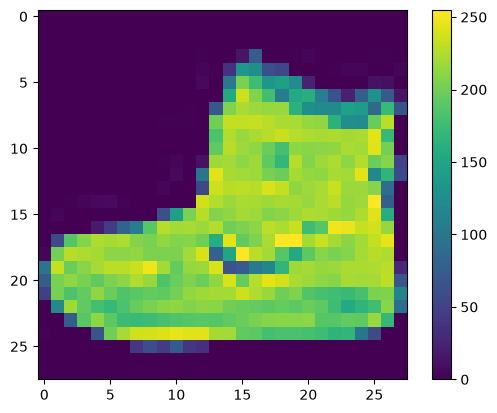

In [8]:
plt.figure()
plt.imshow(train_imgs[0])
plt.colorbar()
plt.grid(False)
plt.show()

In [9]:
train_imgs = train_imgs/255
test_imgs = test_imgs/255

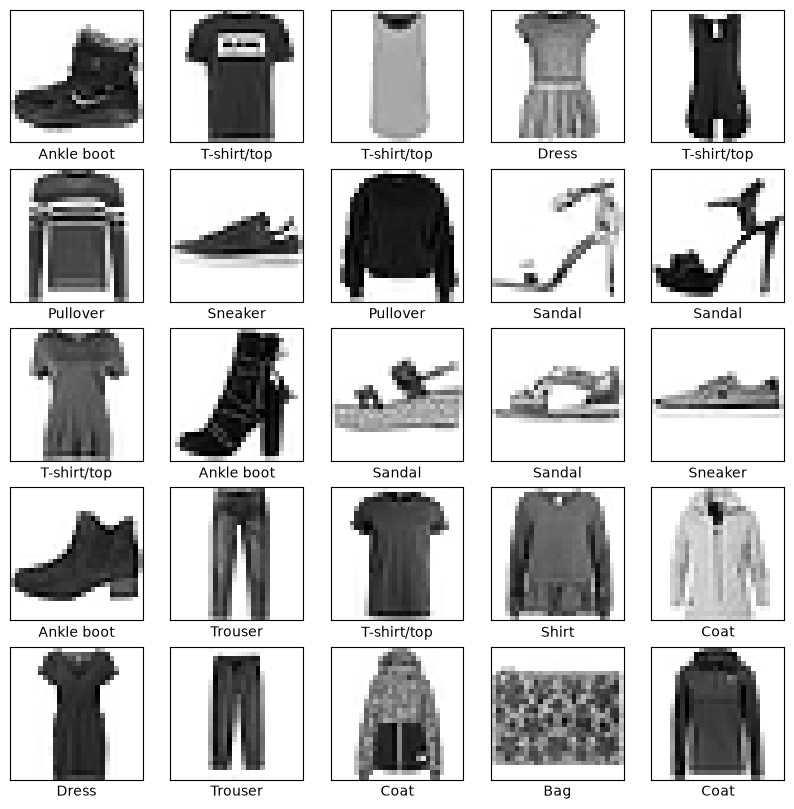

In [10]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_imgs[i], cmap=plt.cm.binary)
    plt.xlabel(Class_names[train_lab[i]])
plt.show()

## Build the model

Building the neural network requires configuring the layers of the model, then compiling the model.


### Set up the layers

The basic building block of a neural network is the [*layer*](https://www.tensorflow.org/api_docs/python/tf/keras/layers). Layers extract representations from the data fed into them. Hopefully, these representations are meaningful for the problem at hand.

Most of deep learning consists of chaining together simple layers. Most layers, such as `tf.keras.layers.Dense`, have parameters that are learned during training.



In [11]:
model = Sequential(
    [layers.Flatten(input_shape = (28 , 28) ),
     layers.Dense(128),
     layers.Dense(10)
      ]

)

C:\Users\trdaxy\.venvs\skyx-tf\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

The first layer in this network, `tf.keras.layers.Flatten`, transforms the format of the images from a two-dimensional array (of 28 by 28 pixels) to a one-dimensional array (of 28 * 28 = 784 pixels). Think of this layer as unstacking rows of pixels in the image and lining them up. This layer has no parameters to learn; it only reformats the data.

After the pixels are flattened, the network consists of a sequence of two `tf.keras.layers.Dense` layers. These are densely connected, or fully connected, neural layers. The first `Dense` layer has 128 nodes (or neurons). The second (and last) layer returns a logits array with length of 10. Each node contains a score that indicates the current image belongs to one of the 10 classes.

### Compile the model

Before the model is ready for training, it needs a few more settings. These are added during the model's [*compile*](https://www.tensorflow.org/api_docs/python/tf/keras/Model#compile) step:

* [*Optimizer*](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers) —This is how the model is updated based on the data it sees and its loss function.
* [*Loss function*](https://www.tensorflow.org/api_docs/python/tf/keras/losses) —This measures how accurate the model is during training. You want to minimize this function to "steer" the model in the right direction.
* [*Metrics*](https://www.tensorflow.org/api_docs/python/tf/keras/metrics) —Used to monitor the training and testing steps. The following example uses *accuracy*, the fraction of the images that are correctly classified.

In [13]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

## Train the model

Training the neural network model requires the following steps:

1. Feed the training data to the model. In this example, the training data is in the `train_imgs` and `train_lab` arrays.
2. The model learns to associate images and labels.
3. You ask the model to make predictions about a test set—in this example, the `test_imgs` array.
4. Verify that the predictions match the labels from the `test_lab` array.

In [14]:
model.fit(train_imgs , train_lab , epochs= 10)

Epoch 1/10


   1/1875 ━━━━━━━━━━━━━━━━━━━━ 30:14 968ms/step - accuracy: 0.0938 - loss: 2.5839

  32/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5576 - loss: 1.2455     

  61/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6327 - loss: 1.0409

  94/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6795 - loss: 0.9191

...

1814/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8566 - loss: 0.4034

1830/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8565 - loss: 0.4038

1846/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8564 - loss: 0.4046

1863/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8562 - loss: 0.4052

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8561 - loss: 0.4057


In [15]:
test_loss , test_acc = model.evaluate(test_imgs, test_lab ,verbose=2)
print(test_acc)

313/313 - 1s - 2ms/step - accuracy: 0.8376 - loss: 0.4638


0.8375999927520752


### Make predictions

With the model trained, you can use it to make predictions about some images.
Attach a softmax layer to convert the model's linear outputs—[logits](https://developers.google.com/machine-learning/glossary#logits)—to probabilities, which should be easier to interpret.



In [16]:
prob_model = Sequential([model , layers.Softmax()])

In [17]:
predictions = prob_model.predict(test_imgs)

  1/313 ━━━━━━━━━━━━━━━━━━━━ 16s 53ms/step

 59/313 ━━━━━━━━━━━━━━━━━━━━ 0s 862us/step

118/313 ━━━━━━━━━━━━━━━━━━━━ 0s 855us/step

177/313 ━━━━━━━━━━━━━━━━━━━━ 0s 858us/step

214/313 ━━━━━━━━━━━━━━━━━━━━ 0s 944us/step

267/313 ━━━━━━━━━━━━━━━━━━━━ 0s 948us/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [18]:
predictions[0]

array([5.3758868e-06, 1.0504866e-07, 4.3532997e-05, 1.3455997e-05,
       2.1039219e-05, 2.9658809e-02, 6.8690519e-05, 1.8772899e-01,
       4.6124109e-03, 7.7784759e-01], dtype=float32)

In [19]:
np.argmax(predictions[1])

np.int64(2)

In [20]:
test_lab[1]

np.uint8(2)